# Plotting for Project 2

In [380]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from colormaps import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [381]:
# np.random.seed(27)

# x0_map = {
#     "Simple1": np.array([[-2,2], [1, -2], [1.5, 1]]),
#     "Simple2": np.array([[2,2], [-1, -1], [3, 3]]),
#     "Simple3": np.array([[1,1,1], [-1, -3, -1], [2, 2, 1]]),
# }
# 10 random initializations in the range [-3, 3]
n_samples = 4
x0_map = {
    "Simple1": np.round(np.random.uniform(-3, 3, (n_samples, 2)), 2),
    "Simple2": np.round(np.random.uniform(-3, 3, (n_samples, 2)), 2),
    "Simple3": np.round(np.random.uniform(-3, 3, (n_samples, 3)), 2),
}

x_best_map = {
    "Simple1": np.array([2/3, 1/np.sqrt(3)]),
    "Simple2": np.array([1,1]),
    "Simple3": np.array([-1/np.sqrt(6), np.sqrt(2/3), -1/np.sqrt(6)]),
}

## Quadratic penalty L-BFGS

In [382]:
from project2_py.helpers import Simple1, Simple2, Simple3
from project2_py.project2 import *

x_hists = {}
f_pen_hists = {}
f_hists = {}
pen_f_hists = {}
g_pen_hists = {}
g_hists = {}
pen_g_hists = {}
c_max_vio_hists = {}

for p_name in [Simple1, Simple2, Simple3]:
    for x0 in x0_map[p_name.__name__]:
        p = p_name()
        x_history, f_pen_history, f_history, pen_f_history, g_pen_history, g_history, pen_g_history = quadratic_penalty_l_bfgs(p.f, p.g, p.c, x0, 2000, p.count)

        # store histories for plotting
        x_hists[(p_name.__name__, tuple(x0))] = x_history
        f_pen_hists[(p_name.__name__, tuple(x0))] = f_pen_history
        f_hists[(p_name.__name__, tuple(x0))] = f_history
        pen_f_hists[(p_name.__name__, tuple(x0))] = pen_f_history
        g_pen_hists[(p_name.__name__, tuple(x0))] = g_pen_history
        g_hists[(p_name.__name__, tuple(x0))] = g_history
        pen_g_hists[(p_name.__name__, tuple(x0))] = pen_g_history

        # print
        print(f"Problem: {p_name.__name__}, x0: {x0}, x_best: {x_history[-1]}, f(x_best): {p.f(x_history[-1])}, c(x_best): {p.c(x_history[-1])}")

Problem: Simple1, x0: [2.1  2.33], x_best: [0. 0.], f(x_best): 0.3849001794597505, c(x_best): [-1. -0.]
Problem: Simple1, x0: [ 0.66 -2.14], x_best: [0.66711288 0.57754346], f(x_best): -0.00038649733653361995, c(x_best): [ 6.69321039e-04 -1.24465633e+00]
Problem: Simple1, x0: [ 2.41 -2.52], x_best: [0.66686495 0.57743612], f(x_best): -0.00017172872240922565, c(x_best): [ 2.97420759e-04 -1.24430107e+00]
Problem: Simple1, x0: [-1.85  1.05], x_best: [0.66711288 0.57754346], f(x_best): -0.0003864972717935733, c(x_best): [ 6.69320927e-04 -1.24465633e+00]
Problem: Simple2, x0: [2.5  1.16], x_best: [0.00137438 0.003343  ], f(x_best): 0.9983694441351586, c(x_best): [ 7.74456544e-04 -1.99528262e+00]
Problem: Simple2, x0: [0.59 0.01], x_best: [0.99999982 1.        ], f(x_best): 1.2987299828655922e-11, c(x_best): [ 1.38122402e-09 -1.82034794e-07]
Problem: Simple2, x0: [ 1.42 -1.07], x_best: [0.00137431 0.00334288], f(x_best): 0.9983694943547353, c(x_best): [ 7.74381385e-04 -1.99528281e+00]
Proble

### Contour plot with feasible region for Simple1

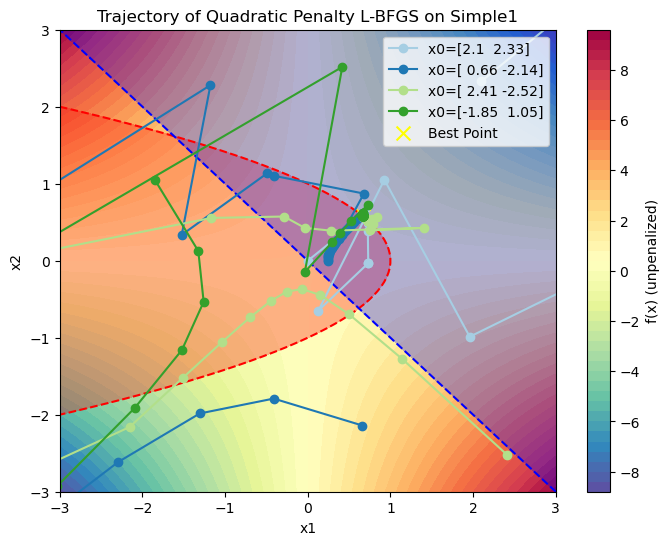

In [ ]:
# heatmap of f for Simple1
p = Simple1()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Quadratic Penalty L-BFGS on Simple1')

# constraints
c1 = X1 + X2**2 - 1
c2 = -X1 - X2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple1"]:
    x_hist = x_hists[("Simple1", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple1"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Contour plot with feasible region for Simple2

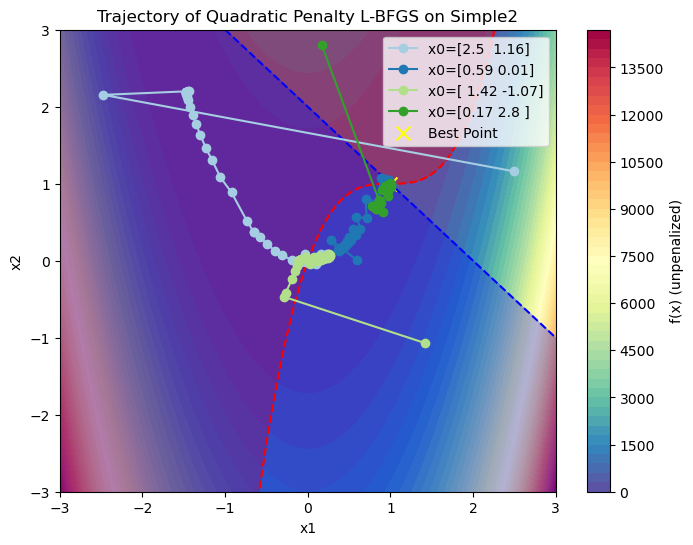

In [384]:
# heatmap of f for Simple2
p = Simple2()
x1 = np.linspace(-3, 3, 100)
x2 = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = np.array([[p.f(np.array([x1, x2])) for x1, x2 in zip(X1.flatten(), X2.flatten())]]).reshape(X1.shape)
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, Z, levels=50, cmap='Spectral_r')
plt.colorbar(label='f(x) (unpenalized)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Trajectory of Quadratic Penalty L-BFGS on Simple2')

# constraints
c1 = (X1-1)**3 - X2 + 1
c2 = X1 + X2 -2

plt.contour(X1, X2, c1, levels=[0], colors="red", linestyles="--")
plt.contourf(X1, X2, c1, levels=[-np.inf, 0], colors="red", alpha=0.3)

plt.contour(X1, X2, c2, levels=[0], colors="blue", linestyles="--")
plt.contourf(X1, X2, c2, levels=[-np.inf, 0], colors="blue", alpha=0.3)

# plot trajectories
i = 0
for x0 in x0_map["Simple2"]:
    x_hist = x_hists[("Simple2", tuple(x0))]
    x_hist = np.array(x_hist)
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', label=f'x0={x0}', color = cmap["cbqual12"][i])
    i += 1

# best point
x_best = x_best_map["Simple2"]
plt.scatter(x_best[0], x_best[1], marker='x', color='yellow', s=100, label='Best Point')

# set limits
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.show()

### Objective function and maximum constraint violation vs iteration for Simple2

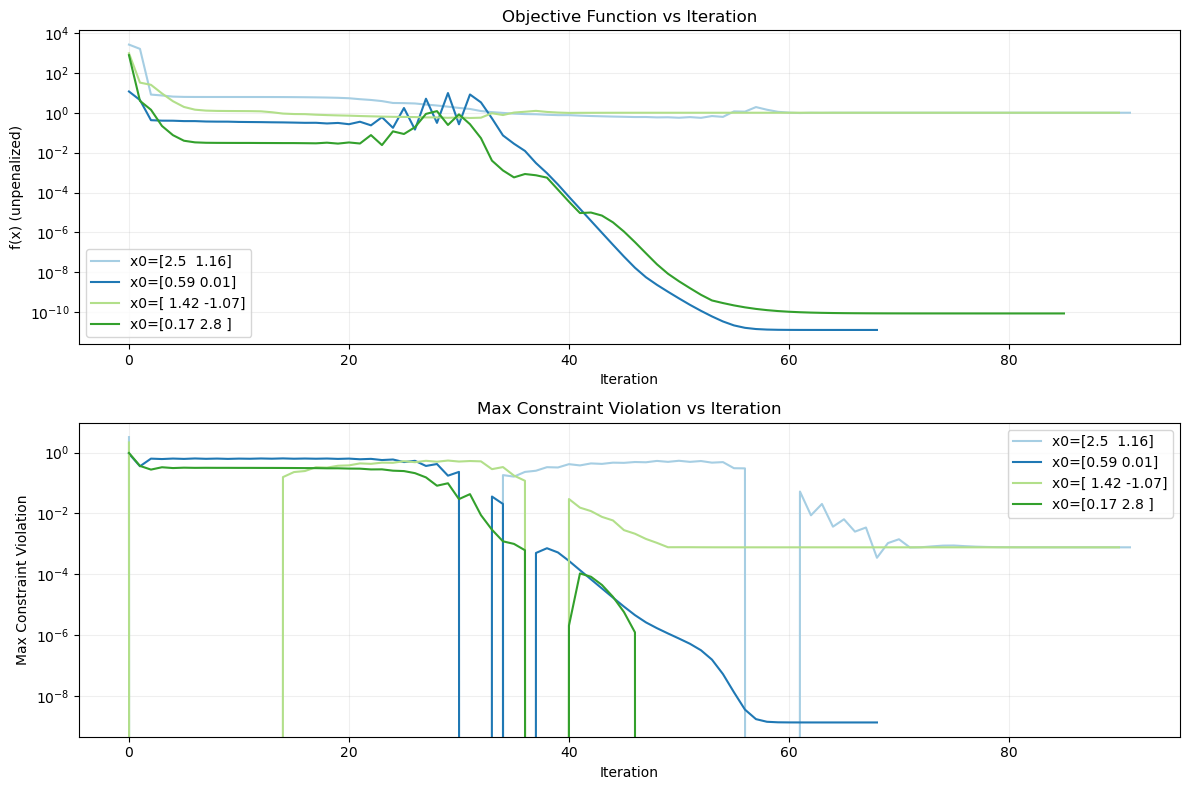

In [390]:
# plot objective function and maximum constraint violation vs iteration for Simple2
plt.figure(figsize=(12, 8))
for i, x0 in enumerate(x0_map["Simple2"]):
    f_history = f_hists[("Simple2", tuple(x0))]

    # plot convergence
    plt.subplot(2,1,1)
    plt.plot(f_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('f(x) (unpenalized)')
    plt.title('Objective Function vs Iteration')
    plt.grid(True, alpha=0.2)
    plt.legend(loc = "best")

    # plot maximum constraint violation
    # get constraint violation history
    c_history = []
    for x in x_hists[("Simple2", tuple(x0))]:
        c1 = (x[0]-1)**3 - x[1] + 1
        c2 = x[0] + x[1] -2
        c_history.append(max(0, max(c1, c2)))
    plt.subplot(2, 1, 2)
    plt.plot(c_history, label=f'x0={x0}', linestyle='-', color = cmap["cbqual12"][i])
    plt.yscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('Max Constraint Violation')
    plt.title('Max Constraint Violation vs Iteration')
    plt.legend(loc = "best")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    